import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# LOAD DATA
dataset = pd.read_csv("Credit_Card_Applications.csv")
X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]
print("Dataset shape:", dataset.shape)


Dataset shape: (690, 16)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  690 non-null    int64  
 1   A1          690 non-null    int64  
 2   A2          690 non-null    float64
 3   A3          690 non-null    float64
 4   A4          690 non-null    int64  
 5   A5          690 non-null    int64  
 6   A6          690 non-null    int64  
 7   A7          690 non-null    float64
 8   A8          690 non-null    int64  
 9   A9          690 non-null    int64  
 10  A10         690 non-null    int64  
 11  A11         690 non-null    int64  
 12  A12         690 non-null    int64  
 13  A13         690 non-null    int64  
 14  A14         690 non-null    int64  
 15  Class       690 non-null    int64  
dtypes: float64(3), int64(13)
memory usage: 86.4 KB
None
         CustomerID          A1          A2          A3          A4  \
count  6.900000e+02  690.0000

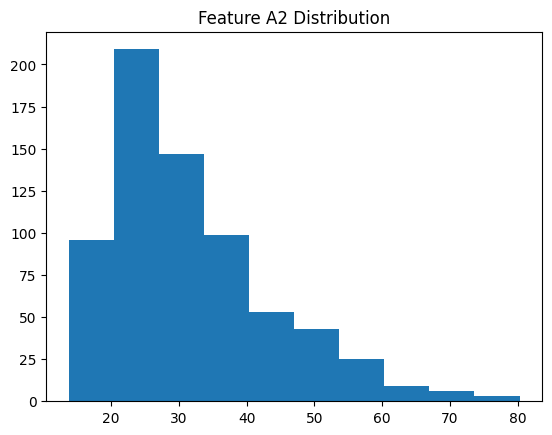

In [3]:
# EDA
print(dataset.info())
print(dataset.describe())
print(dataset["Class"].value_counts())

plt.hist(dataset["A2"])
plt.title("Feature A2 Distribution")
plt.show()


In [4]:
# SPLIT
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [5]:
# SCALING
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


In [6]:
# TRAIN MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(n_estimators=100)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

models = {
    "Logistic Regression": lr,
    "Random Forest": rf
}


===== Logistic Regression =====
Accuracy: 0.8768115942028986
ROC AUC: 0.9033130493576742
Confusion Matrix:
 [[79  8]
 [ 9 42]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.91      0.90        87
           1       0.84      0.82      0.83        51

    accuracy                           0.88       138
   macro avg       0.87      0.87      0.87       138
weighted avg       0.88      0.88      0.88       138



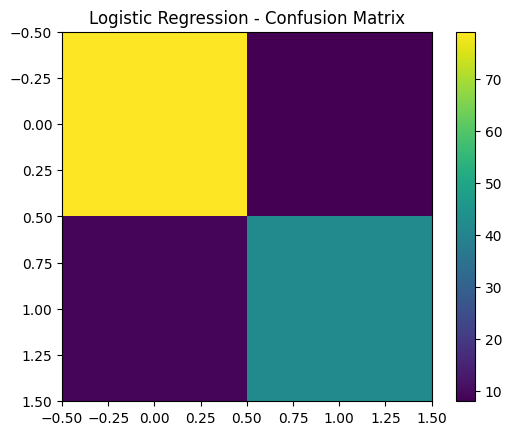

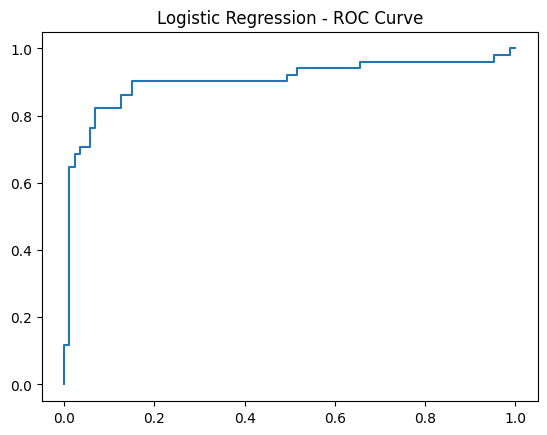

===== Random Forest =====
Accuracy: 0.8840579710144928
ROC AUC: 0.9257381113364886
Confusion Matrix:
 [[81  6]
 [10 41]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.93      0.91        87
           1       0.87      0.80      0.84        51

    accuracy                           0.88       138
   macro avg       0.88      0.87      0.87       138
weighted avg       0.88      0.88      0.88       138



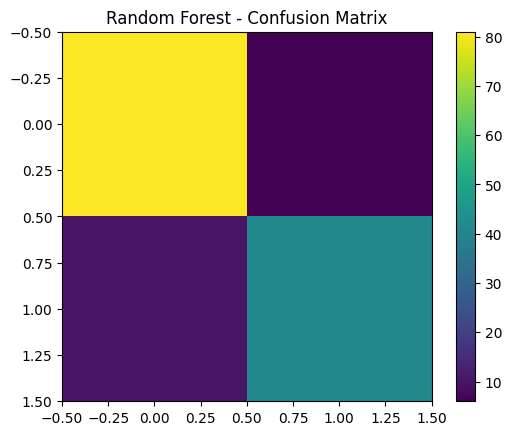

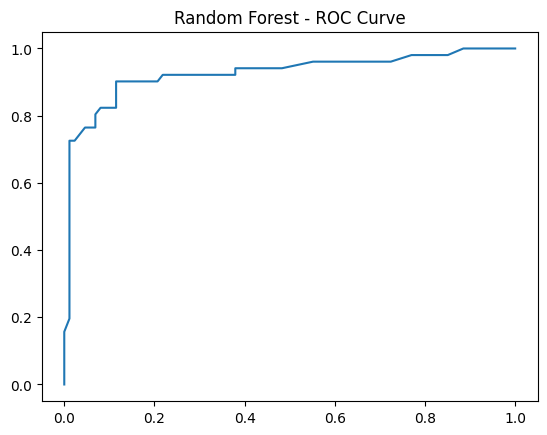

In [7]:
# EVALUATION
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

for name, model in models.items():
    print(f"===== {name} =====")

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print("Accuracy:", acc)
    print("ROC AUC:", roc_auc)
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", report)

    plt.imshow(cm)
    plt.title(f"{name} - Confusion Matrix")
    plt.colorbar()
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr)
    plt.title(f"{name} - ROC Curve")
    plt.show()
